# 03. Models Training and Evaluation:
    • Model0 ScratchResNet 
    • Model1 ResNet18    
    • Model2 ResNet18 w/ Temporal Vector



In [1]:
# Step 1. Setup and Imports
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

import subprocess

def get_repo_root():
    return subprocess.check_output(['git', 'rev-parse', '--show-toplevel']).decode('utf-8').strip()
repo_root = get_repo_root()
print(repo_root)

src_path = os.path.join(repo_root, 'src')
# Add src_path to sys.path if not already present
if src_path not in sys.path:
    sys.path.insert(0, repo_root)
    sys.path.insert(0, src_path)
#sys.path.append(str(repo_root))

# Set random seeds for reproducibility
RANDOM_SEED = 42


import logging
# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(filename)s:%(lineno)d - %(funcName)s() - %(message)s"
)
logger = logging.getLogger(__name__)

def set_seed(seed: int):
    # Python built‐ins
    random.seed(seed)
    np.random.seed(seed)

    # PyTorch CPU & CUDA
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # PyTorch MPS (Apple GPU)
    if torch.backends.mps.is_available():
        try:
            # New in PyTorch 2+: seeds MPS generator
            torch.mps.manual_seed(seed)
        except AttributeError:
            # Fallback pre–PyTorch 2.0: no direct MPS seeding, CPU generator only
            torch.manual_seed(seed)

    # Enforce deterministic algorithms where possible
    torch.use_deterministic_algorithms(True)
    # For CUDA backends only:
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# Example usage
set_seed(RANDOM_SEED)
print(f"Project root: {repo_root}")


/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan
Project root: /Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan


In [2]:
# Step 2. Import Required Classes 

import importlib
import wildscan_ml_system
import custom_models
import trainer


importlib.reload(wildscan_ml_system)
importlib.reload(custom_models)
importlib.reload(trainer)

from custom_models import AnimalTemporalClassifier, AnimalClassifier, ScratchResNet
from trainer import WildScanTrainer as Trainer
from wildscan_ml_system import PretrainingPipeline, SystemConfig  



In [3]:
# Step 3: Create SystemConfig for PretrainingPipeline Only
def create_notebook_config():
    
    """Create configuration optimized for notebook pretraining"""
    def get_device():
        if torch.cuda.is_available():
            return "cuda"
        elif torch.backends.mps.is_available():
            return "mps"
        else:
            return "cpu"

    config = SystemConfig(
        # Project settings
        project_name="notebook_pretraining",
        experiment_name="pretraining_experiment",

        device = get_device(),
        # Data paths
        train_data_path="./data_split/train-meta.csv", #benchmark eccv18 1st year
        val_data_path="./data_split/val-meta.csv", #benchmark eccv18 1st year (calibration data)
        test_data_path="./data_split/test-meta.csv",#benchmark eccv18 1st year (in distribution test set)
        ood_data_path="./data_split/year1/val-meta.csv", # out of distribution data for year 1
        

        # Preprocessed images path
        preprocessed_images_path= "../dataset/cct_resized/",

        # label mapping path
        label2idx_path = "./data_split/label_mapping.json",

        # models to use
        models_to_use = [0, 1, 2],
        
        # Training settings (notebook-friendly)
        batch_size=32,
        learning_rate=1e-4,
        weight_decay=0,
        patience = 0,
        epochs=10,  # Reduced for notebook

        # criterion
        criterion=nn.CrossEntropyLoss(),
        
        # Pipeline settings - ONLY PRETRAINING
        enable_pretraining_pipeline=True,
        enable_production_pipeline=False,  # Not needed

        # model training output dir
        training_output_dir="./pretrained_models",
        
        # Logging
        output_dir="./notebook_outputs",
        log_level="INFO",
        #console_logging=False,
        #include_full_file_paths=False  # Cleaner for notebook
        
    )
    
    
    
    return config

# Create configuration
config = create_notebook_config()
print("📝 Configuration created for notebook pretraining")
print(f"   - Device: {config.device}")
print(f"   - Output: {config.output_dir}")
print(f"   - Epochs: {config.epochs}")

📝 Configuration created for notebook pretraining
   - Device: mps
   - Output: ./notebook_outputs
   - Epochs: 10


In [5]:
# Step 4: Initialize PretrainingPipeline Directly
# Create the pipeline instance WITHOUT MasterMLSystem
pretraining_pipeline = []
pretraining_pipeline = PretrainingPipeline(config)

print("🔬 PretrainingPipeline initialized successfully!")
#print(f"   - Default optimizer: {pretraining_pipeline.default_trainer_config.optimizer_class.__name__}")
#print(f"   - Default epochs: {pretraining_pipeline.default_trainer_config.epochs}")

🔬 PretrainingPipeline initialized successfully!


2025-08-09 07:35:19,005 - INFO - wildscan_ml_system.py:483 - run_pipeline() - 🔬 Starting Pretraining Pipeline...
2025-08-09 07:35:19,006 - INFO - wildscan_ml_system.py:229 - setup_datasets() - Setting up datasets for pretraining...
2025-08-09 07:35:19,007 - DEBUG - custom_datasets.py:56 - __init__() - input local csv: ./data_split/train-meta.csv
2025-08-09 07:35:19,046 - INFO - custom_datasets.py:70 - __init__() - Dataset shape: (9088, 16)
2025-08-09 07:35:19,047 - DEBUG - custom_datasets.py:84 - __init__() - no need to initialize s3fs since using local directory for dataset
2025-08-09 07:35:19,048 - INFO - custom_datasets.py:130 - __init__() - loading label2idx mapping from provided dict
2025-08-09 07:35:19,048 - INFO - custom_datasets.py:139 - __init__() - Dataset initialized with 9088 samples.
2025-08-09 07:35:19,048 - DEBUG - custom_datasets.py:56 - __init__() - input local csv: ./data_split/val-meta.csv
2025-08-09 07:35:19,055 - INFO - custom_datasets.py:70 - __init__() - Dataset 

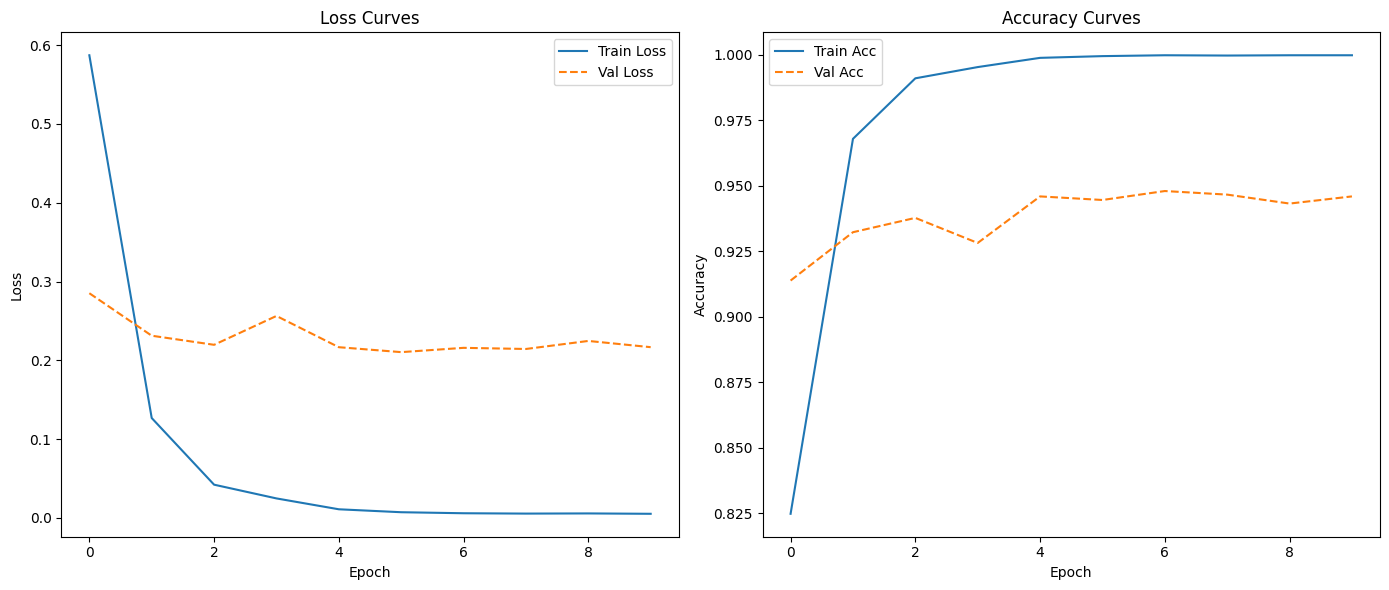

2025-08-09 07:45:55,735 - INFO - wildscan_ml_system.py:343 - train_models() - Model No 1 : AnimalClassifier_ResNet18 loaded with best weights.
2025-08-09 07:45:55,735 - INFO - wildscan_ml_system.py:305 - train_models() - Training Model No 2 : AnimalTemporalClassifier_ResNet18...
2025-08-09 07:45:56,001 - INFO - trainer.py:69 - __init__() - Using loss function: CrossEntropyLoss
2025-08-09 07:45:56,001 - INFO - trainer.py:74 - __init__() - Using learning rate scheduler: ReduceLROnPlateau with params: {'factor': 0.1, 'optimizer': Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
), 'default_min_lr': 0, 'min_lrs': [0], 'patience': 0, 'cooldown': 0, 'cooldown_counter': 0, 'mode': 'min', 'threshold': 0.0001, 'threshold_mode': 'rel', 'eps': 1e-08, 'last_epoch': 0, '_last_lr': [0.0001], 'mode_

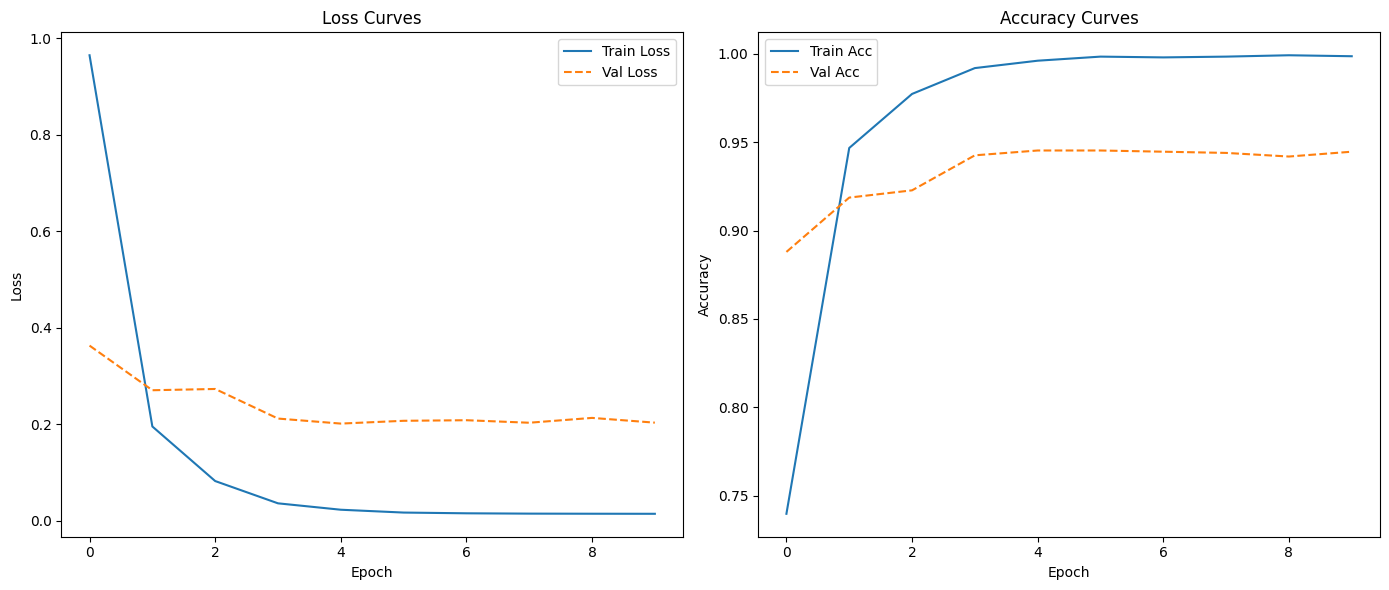

2025-08-09 07:56:24,616 - INFO - wildscan_ml_system.py:343 - train_models() - Model No 2 : AnimalTemporalClassifier_ResNet18 loaded with best weights.
2025-08-09 07:56:24,618 - INFO - wildscan_ml_system.py:348 - evaluate_models() - Evaluating models...
2025-08-09 07:56:24,619 - INFO - wildscan_ml_system.py:354 - evaluate_models() - Found 2 model(s) to evaluate.
2025-08-09 07:56:24,620 - INFO - wildscan_ml_system.py:361 - evaluate_models() - Evaluating Model No 1 : AnimalClassifier_ResNet18...
2025-08-09 07:56:24,651 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 07:56:44,410 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]



=== MODEL AnimalClassifier_ResNet18 ===
Accuracy: 0.9101279910962715
F1-score (macro): 0.8027567536744227
ROC-AUC: 0.9940524875091041
Classification Report:
               precision    recall  f1-score   support

         car       0.98      1.00      0.99       648
      coyote       0.89      0.93      0.91       526
         dog       0.81      0.93      0.87       299
      bobcat       0.92      0.88      0.90       445
      rabbit       0.88      0.94      0.91      1004
        deer       1.00      0.69      0.82        13
     opossum       0.96      0.93      0.95      2404
     raccoon       0.87      0.93      0.90       507
    squirrel       0.79      0.84      0.82       329
         cat       0.92      0.86      0.89       666
        bird       0.73      0.45      0.56       227
       skunk       0.83      0.93      0.88        58
      rodent       0.79      0.93      0.86        61
         fox       0.00      0.00      0.00         1

    accuracy                 

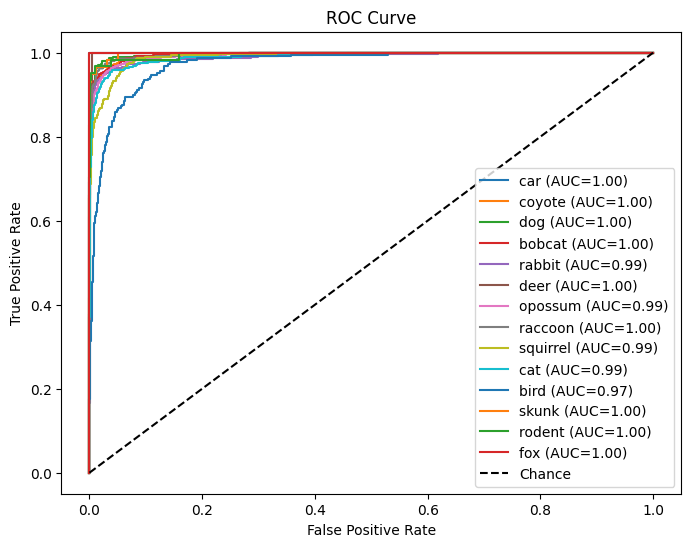

2025-08-09 07:56:44,695 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 07:57:12,507 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  6  7  8  9 10 11 12]
2025-08-09 07:57:12,508 - WARNING - evaluator.py:99 - evaluate() - Mismatch between present classes in evaluation set and model label mapping. Present classes: [ 0  1  2  3  4  6  7  8  9 10 11 12], Model classes: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])



=== MODEL AnimalClassifier_ResNet18 ===
Accuracy: 0.7875417130144605
F1-score (macro): 0.6164122766420329
ROC-AUC: not available
Classification Report:
               precision    recall  f1-score   support

         car       0.98      1.00      0.99       747
      coyote       0.64      0.79      0.71      1090
         dog       0.25      0.51      0.33       234
      bobcat       0.95      0.71      0.81      1983
      rabbit       0.74      0.86      0.79       478
        deer       0.00      0.00      0.00         0
     opossum       0.86      0.92      0.89      2438
     raccoon       0.92      0.69      0.79      2647
    squirrel       0.55      0.93      0.70       430
         cat       0.49      0.62      0.54       395
        bird       0.35      0.43      0.38        82
       skunk       0.89      0.84      0.86       249
      rodent       0.14      0.40      0.21        15
         fox       0.00      0.00      0.00         0

    accuracy                      

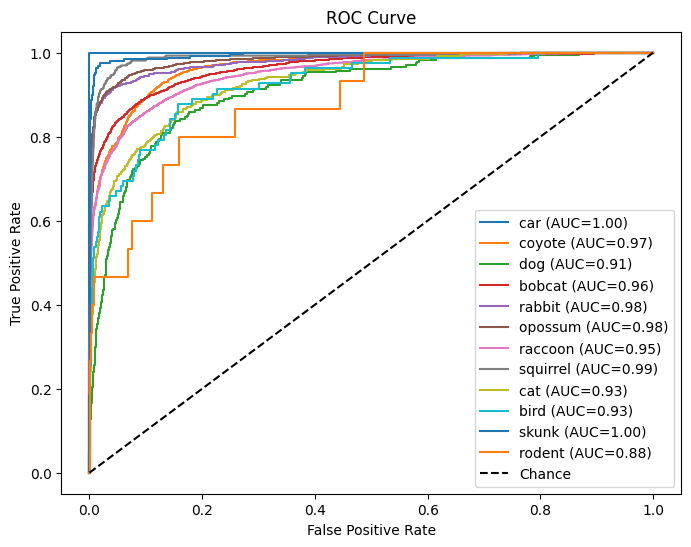

2025-08-09 07:57:12,683 - INFO - wildscan_ml_system.py:361 - evaluate_models() - Evaluating Model No 2 : AnimalTemporalClassifier_ResNet18...
2025-08-09 07:57:12,687 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 07:57:30,723 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]



=== MODEL AnimalTemporalClassifier_ResNet18 ===
Accuracy: 0.902615470228158
F1-score (macro): 0.7847853778058764
ROC-AUC: 0.9900853196909836
Classification Report:
               precision    recall  f1-score   support

         car       0.99      1.00      0.99       648
      coyote       0.86      0.91      0.88       526
         dog       0.79      0.92      0.85       299
      bobcat       0.90      0.89      0.90       445
      rabbit       0.89      0.94      0.91      1004
        deer       1.00      0.62      0.76        13
     opossum       0.97      0.92      0.94      2404
     raccoon       0.86      0.93      0.89       507
    squirrel       0.78      0.84      0.81       329
         cat       0.88      0.86      0.87       666
        bird       0.74      0.42      0.54       227
       skunk       0.77      0.91      0.83        58
      rodent       0.71      0.90      0.80        61
         fox       0.00      0.00      0.00         1

    accuracy          

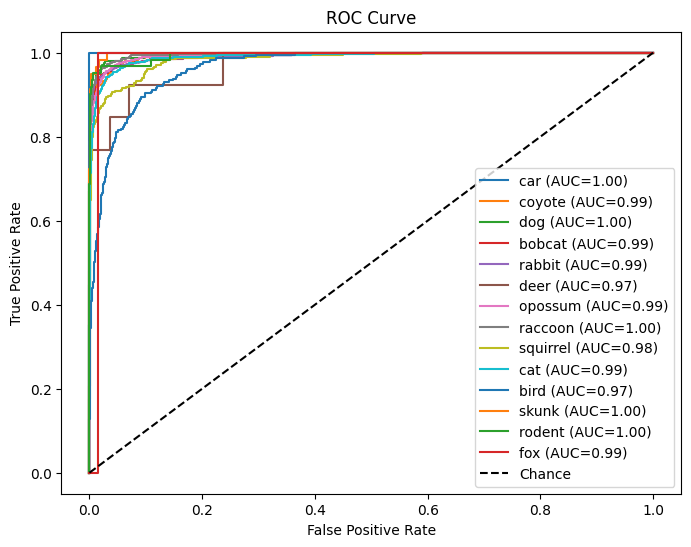

2025-08-09 07:57:30,929 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 07:57:58,116 - INFO - evaluator.py:97 - evaluate() - Present classes in evaluation set: [ 0  1  2  3  4  6  7  8  9 10 11 12]
2025-08-09 07:57:58,117 - WARNING - evaluator.py:99 - evaluate() - Mismatch between present classes in evaluation set and model label mapping. Present classes: [ 0  1  2  3  4  6  7  8  9 10 11 12], Model classes: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])



=== MODEL AnimalTemporalClassifier_ResNet18 ===
Accuracy: 0.7949573600296626
F1-score (macro): 0.622516531190678
ROC-AUC: not available
Classification Report:
               precision    recall  f1-score   support

         car       0.98      1.00      0.99       747
      coyote       0.71      0.83      0.77      1090
         dog       0.29      0.59      0.39       234
      bobcat       0.88      0.71      0.78      1983
      rabbit       0.79      0.85      0.82       478
        deer       0.00      0.00      0.00         0
     opossum       0.92      0.91      0.91      2438
     raccoon       0.92      0.69      0.79      2647
    squirrel       0.59      0.94      0.73       430
         cat       0.41      0.65      0.50       395
        bird       0.34      0.48      0.40        82
       skunk       0.87      0.88      0.87       249
      rodent       0.09      0.40      0.14        15
         fox       0.00      0.00      0.00         0

    accuracy               

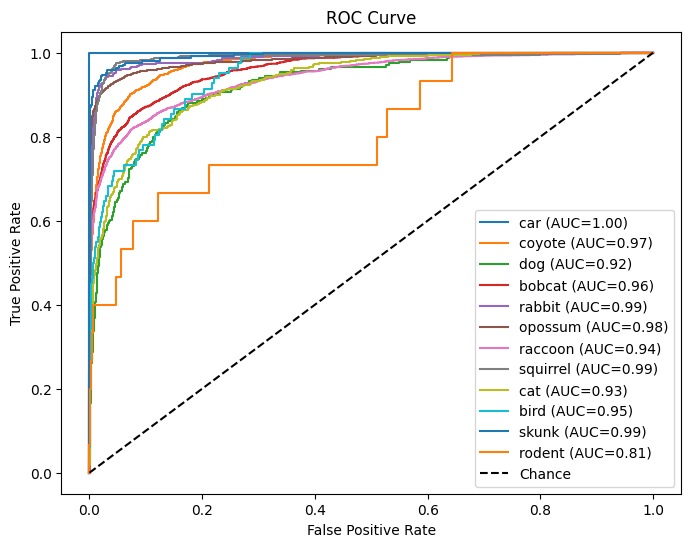

2025-08-09 07:57:58,281 - INFO - wildscan_ml_system.py:389 - evaluate_confidences() - Evaluating Confidence Metrics for Model No 1 : AnimalClassifier_ResNet18...
2025-08-09 07:57:58,281 - INFO - wildscan_ml_system.py:390 - evaluate_confidences() - Setup calibration data from validation set for this model...
2025-08-09 07:57:58,283 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 07:58:02,294 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps


Dataset  7188 test samples, 14 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.025537,0.025128,1.599135
1,Overconfidence Error,0.025154,-0.000651,0.000000
2,Brier Score,0.055341,0.057974,0.000000


2025-08-09 07:58:20,656 - DEBUG - font_manager.py:1379 - _findfont_cached() - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=14.0.
2025-08-09 07:58:20,659 - DEBUG - font_manager.py:1391 - _findfont_cached() - findfont: score(FontEntry(fname='/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2025-08-09 07:58:20,664 - DEBUG - font_manager.py:1391 - _findfont_cached() - findfont: score(FontEntry(fname='/opt/miniconda3/envs/pytorch_base/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2025-08-09 07:58:20,665 - DEBUG - font_manager.py:1391 - _findfont_cached() - findfont: score(FontEntry(fname='/opt/miniconda3/envs/pytorch

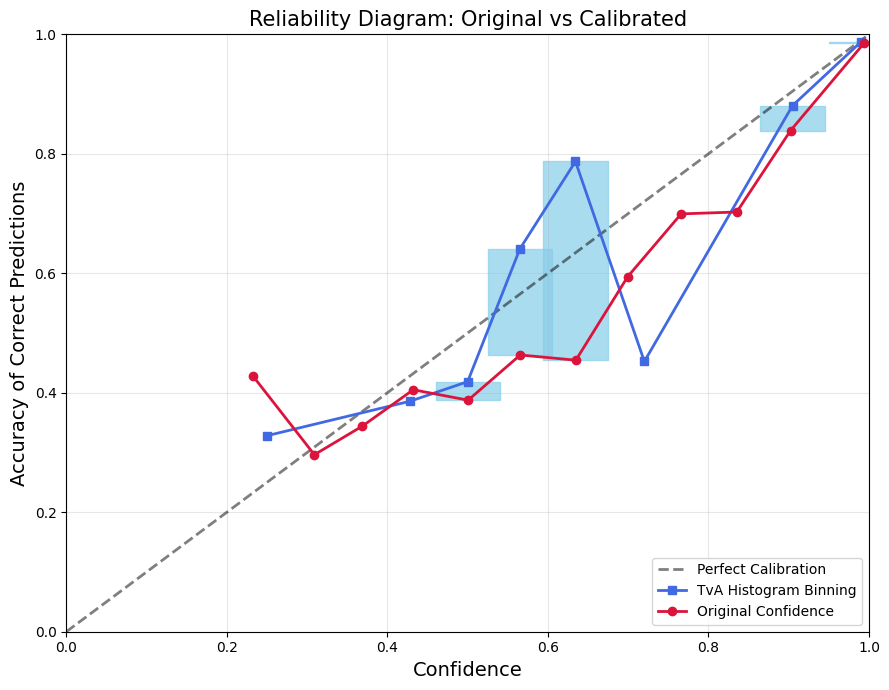

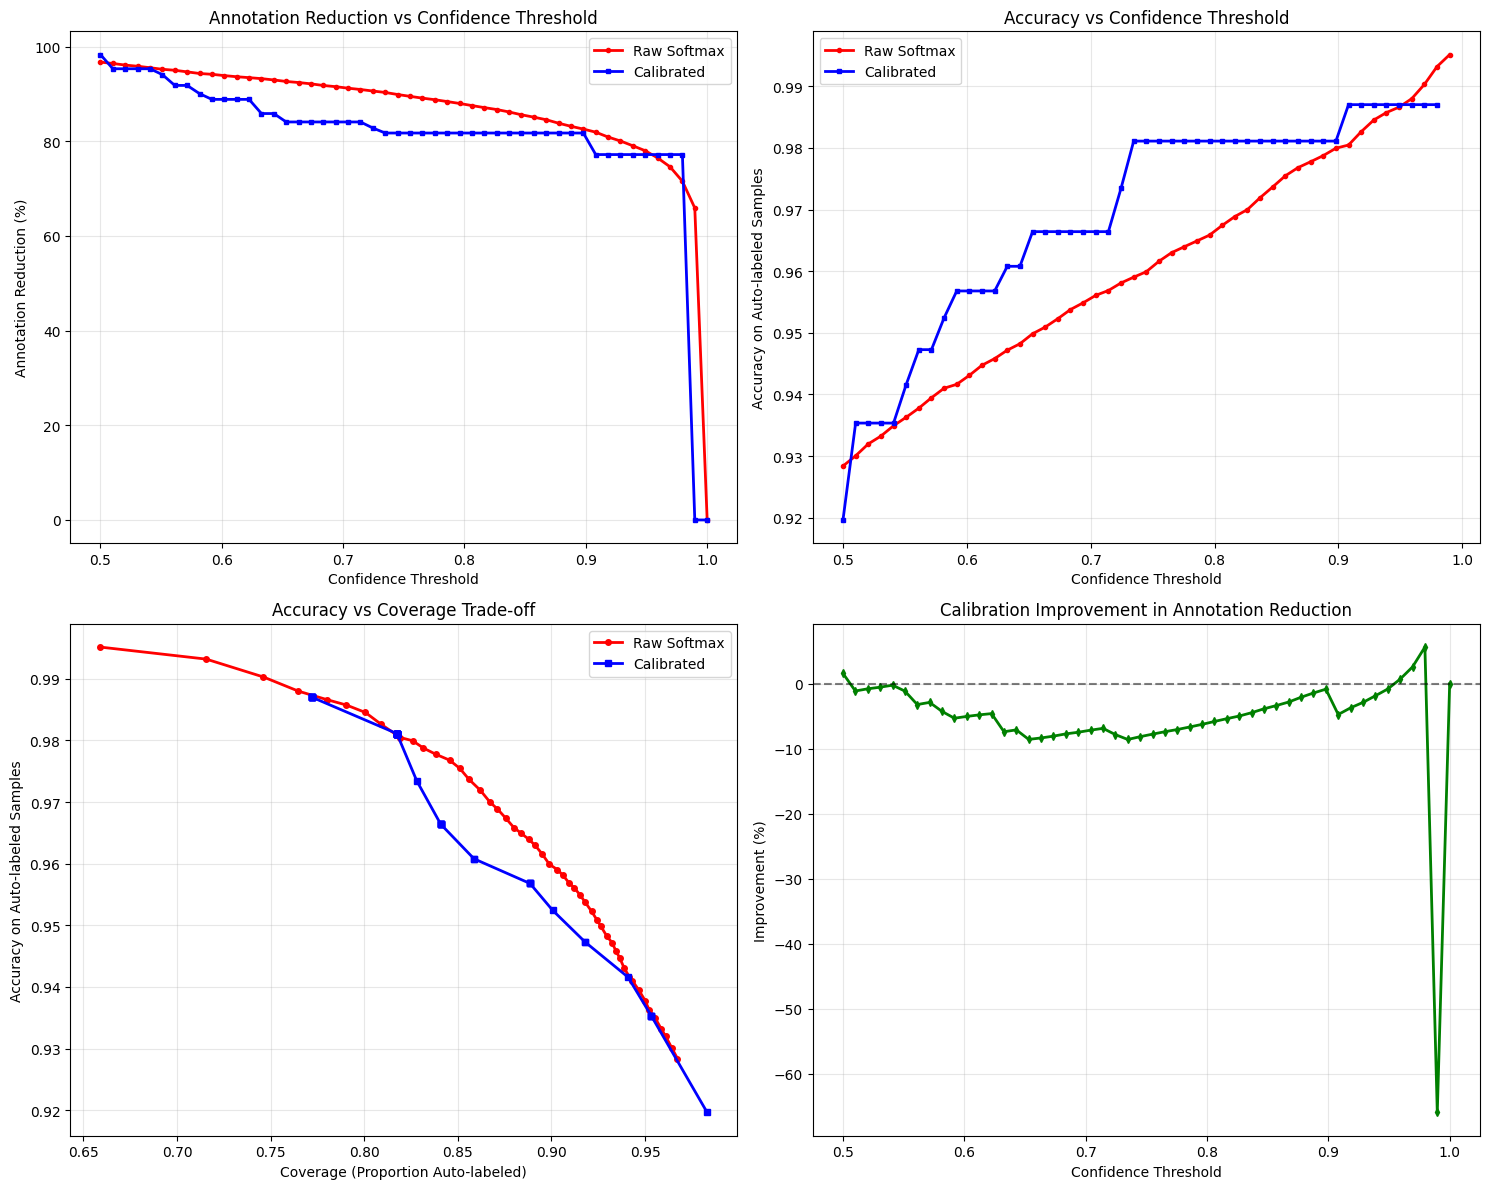

2025-08-09 07:58:22,076 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 07:58:49,080 - INFO - wildscan_ml_system.py:442 - evaluate_confidences() - Evaluating confidence metrics on out-of-distribution test set...


Dataset  10788 test samples, 12 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.100894,0.066465,34.124127
1,Overconfidence Error,0.100894,0.066465,0.000000
2,Brier Score,0.130274,0.124104,0.000000


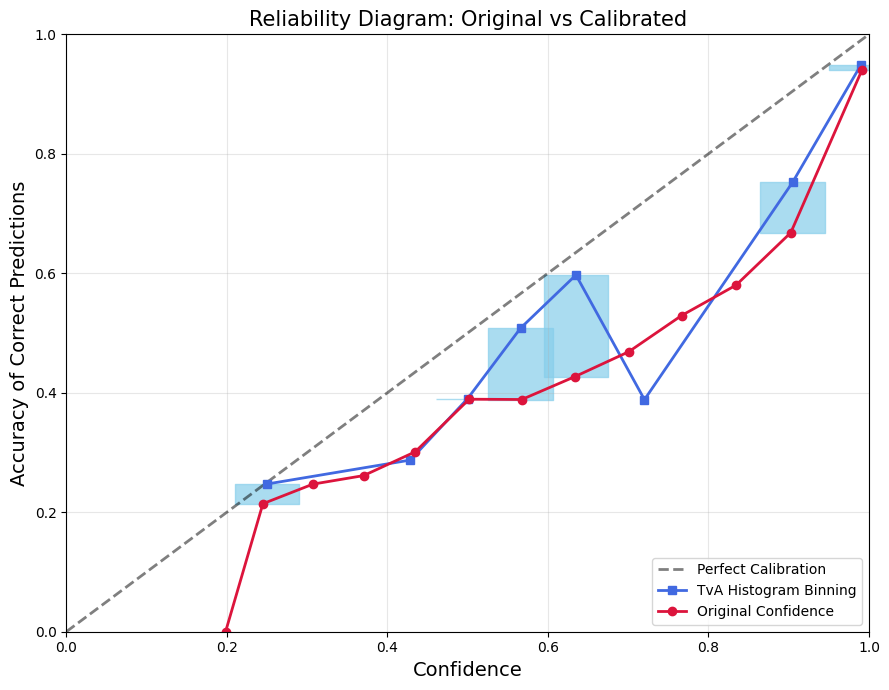

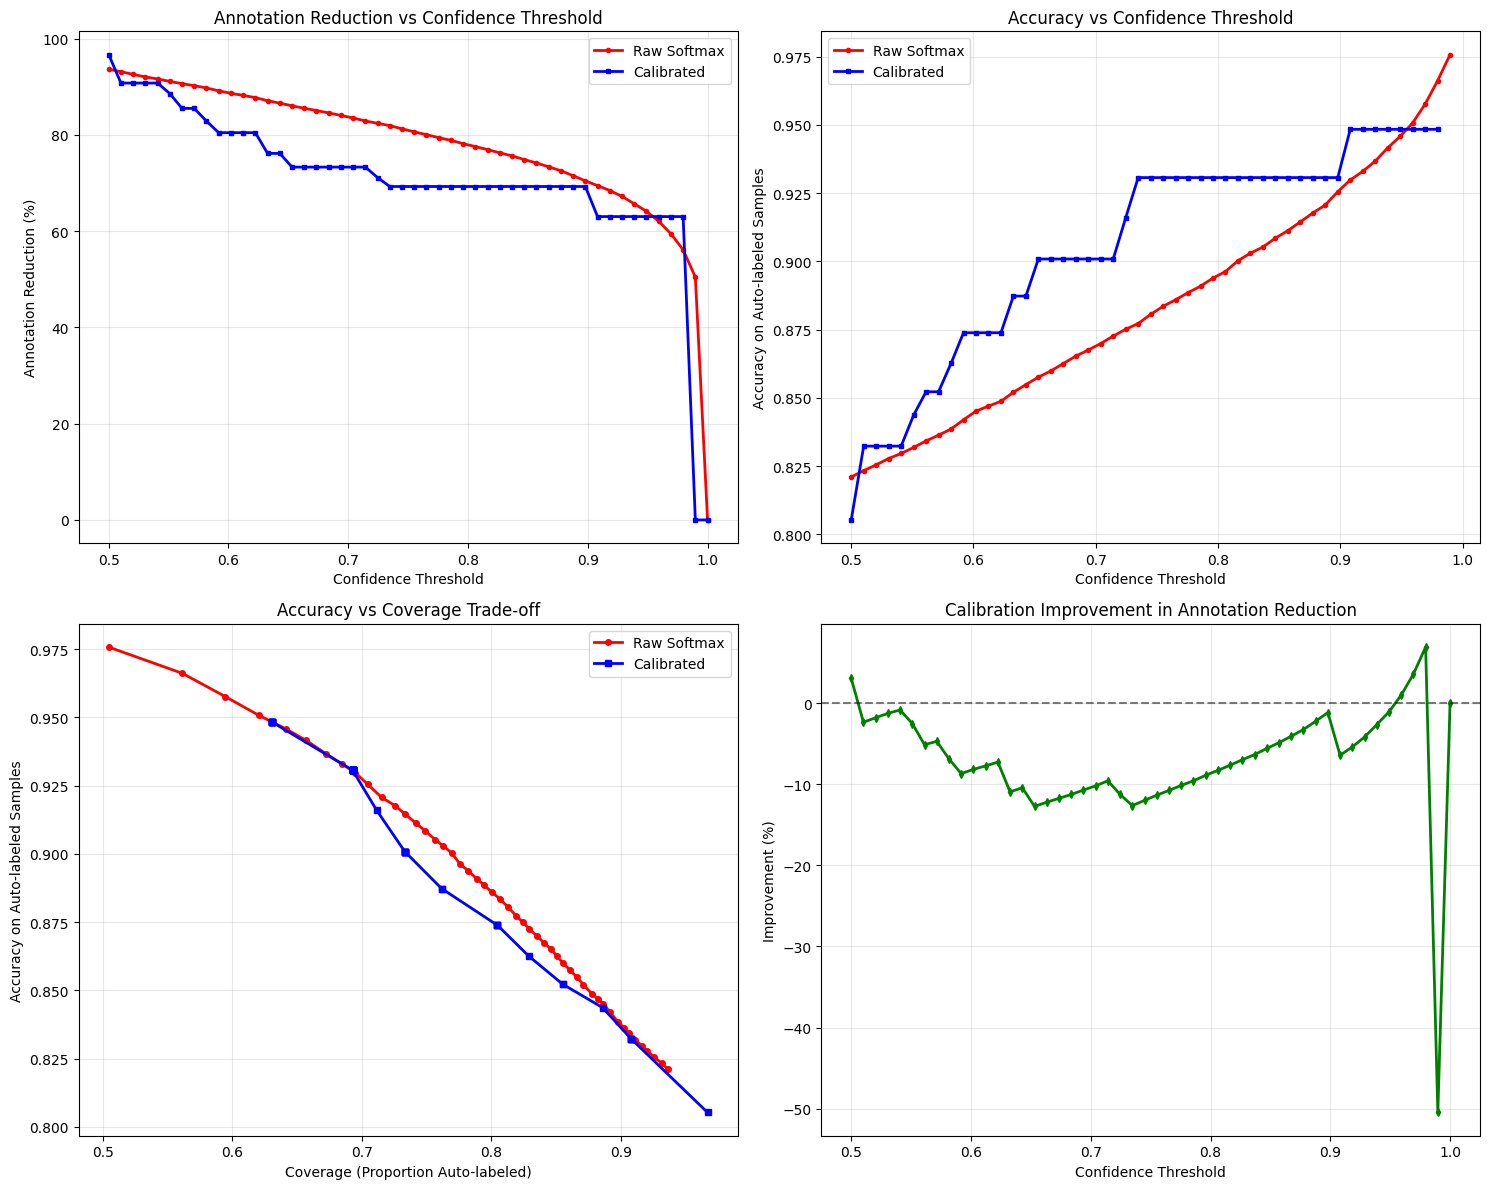

2025-08-09 07:58:49,505 - INFO - wildscan_ml_system.py:389 - evaluate_confidences() - Evaluating Confidence Metrics for Model No 2 : AnimalTemporalClassifier_ResNet18...
2025-08-09 07:58:49,505 - INFO - wildscan_ml_system.py:390 - evaluate_confidences() - Setup calibration data from validation set for this model...
2025-08-09 07:58:49,507 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 07:58:53,463 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps


Dataset  7188 test samples, 14 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.026550,0.017767,33.07936
1,Overconfidence Error,0.026433,0.007213,0.00000
2,Brier Score,0.055736,0.058536,0.00000


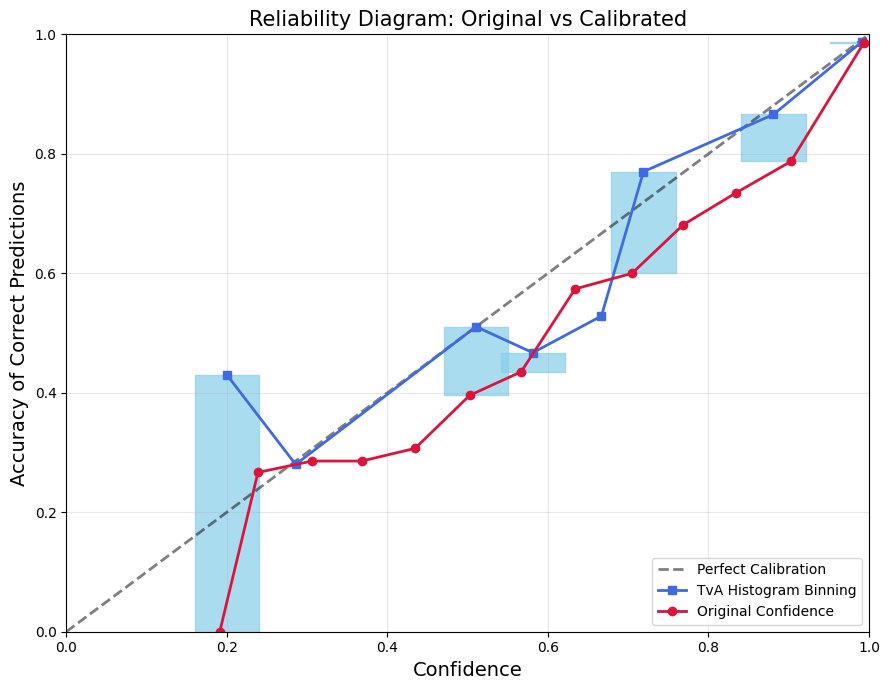

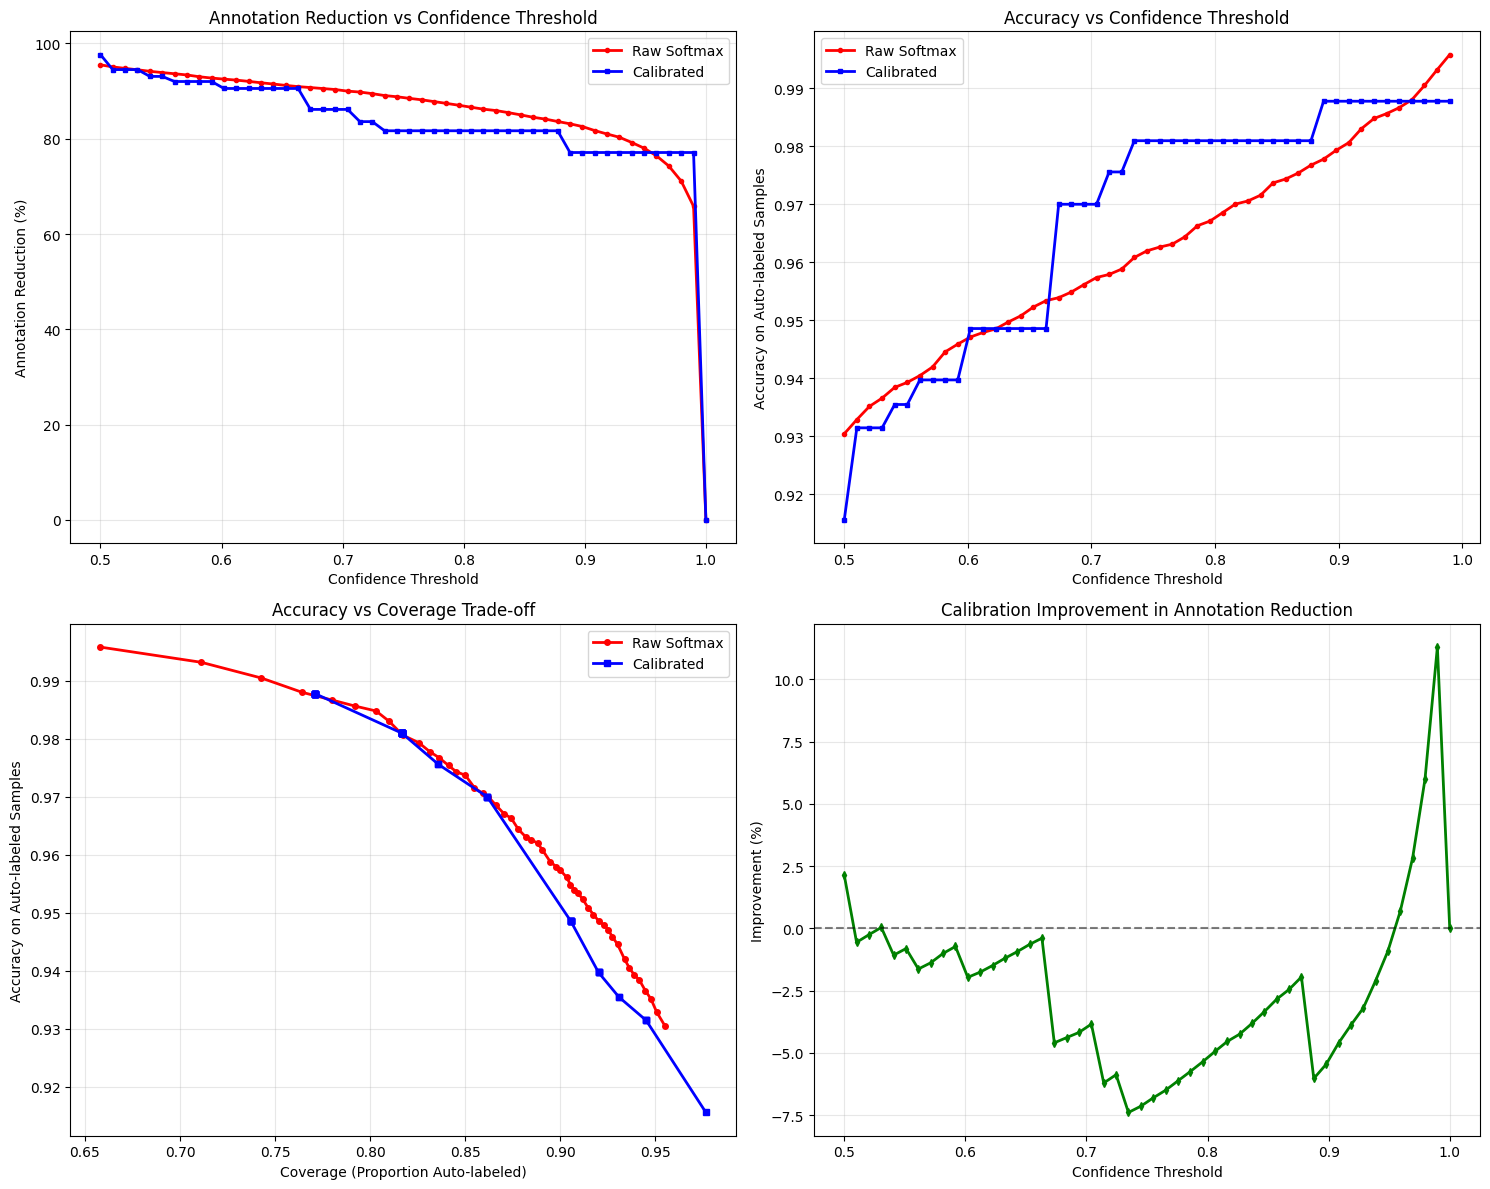

2025-08-09 07:59:11,680 - INFO - evaluator.py:39 - __init__() - Model initialized on device: mps
2025-08-09 07:59:38,664 - INFO - wildscan_ml_system.py:442 - evaluate_confidences() - Evaluating confidence metrics on out-of-distribution test set...


Dataset  10788 test samples, 12 classes


,Metric,Original,Calibrated,Improvement (%)
0,ECE,0.082629,0.065706,20.481022
1,Overconfidence Error,0.082536,0.053751,0.000000
2,Brier Score,0.118940,0.119549,0.000000


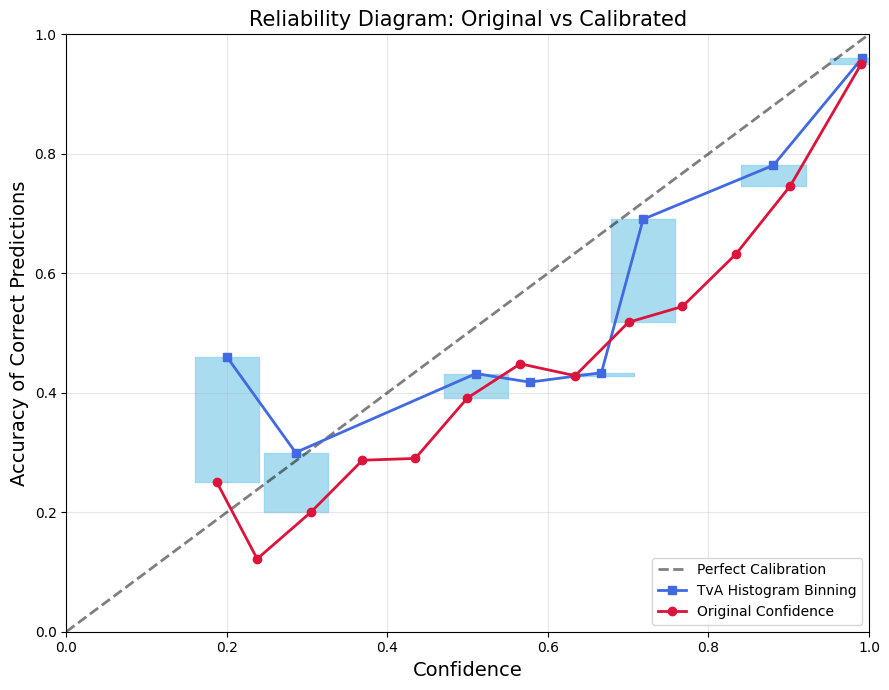

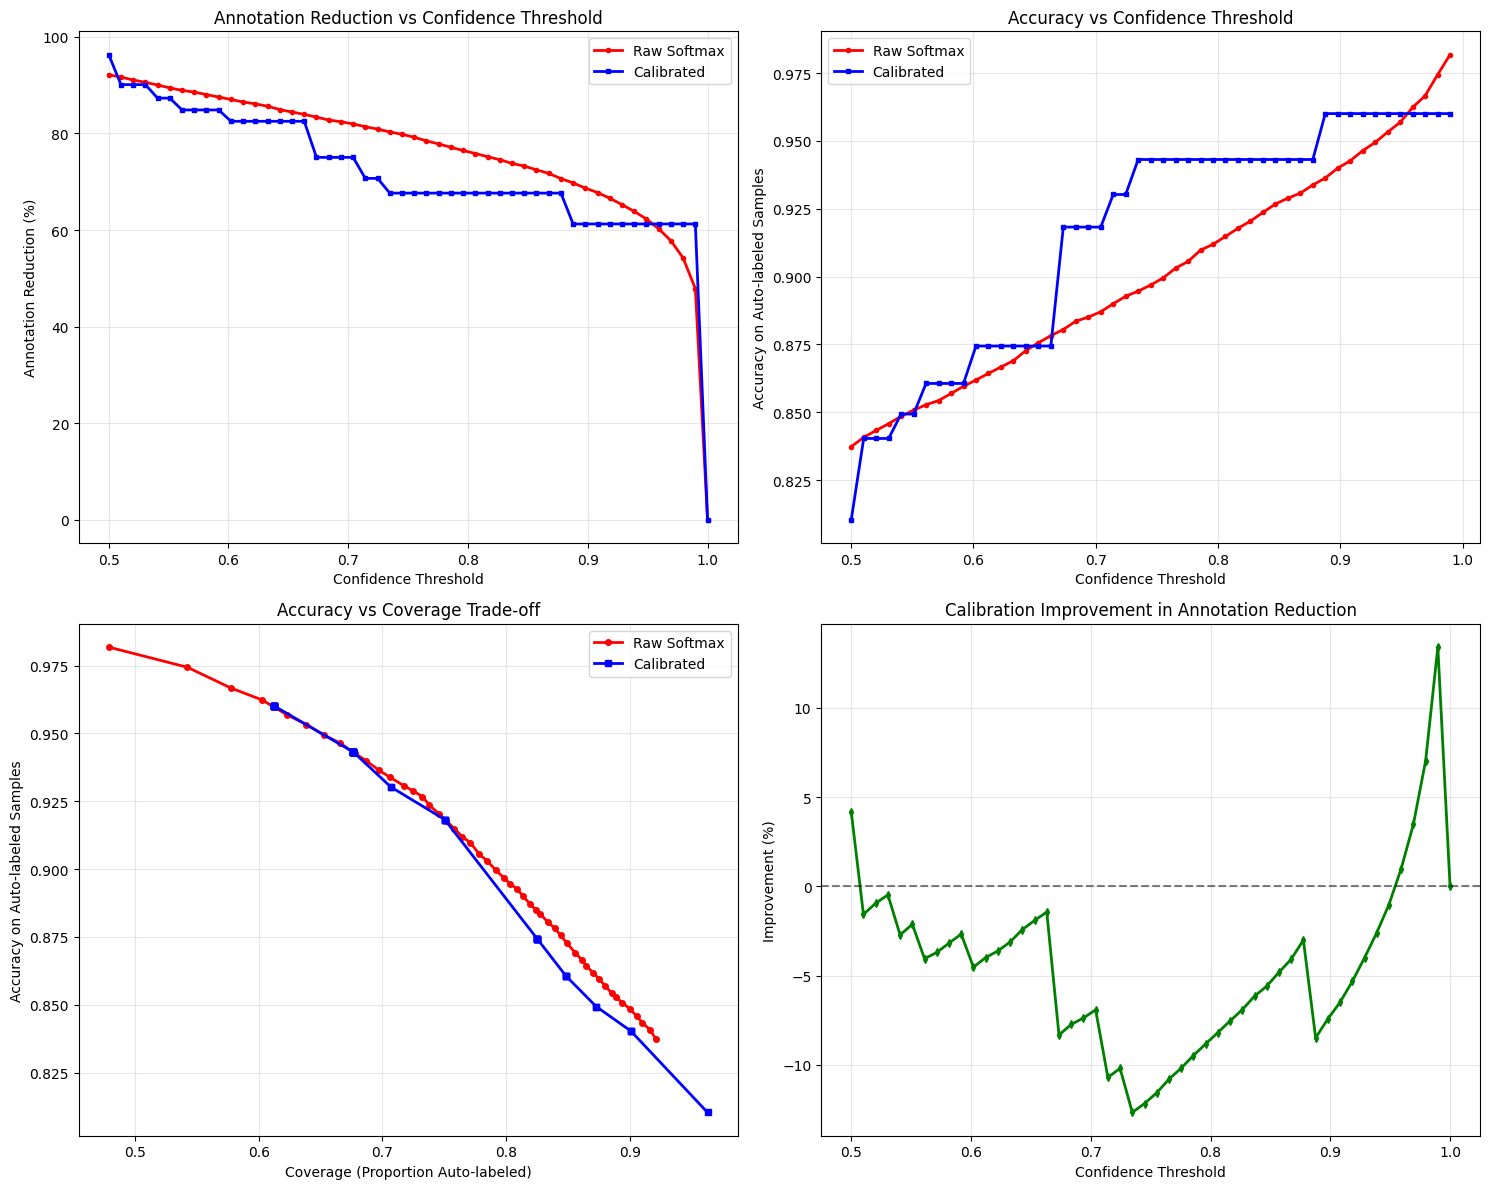

{'models': {1: AnimalClassifier(
    (cnn): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d

In [6]:
# Step 5: Run PretrainingPipeline Directly
pretraining_pipeline.run_pipeline()

In [ ]:
pretraining_pipeline.

---
# Analysis

1. Overfitting even on in-distribution benchmark validation set. Explore architecture changes in the final hidden layers prior to the classification layer.

2. Input data is highly imbalanced. Explore augmentation to reduce overfitting